#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> Hierarchical Clustering

K-Means: Each data point belongs to the nearest center.

Issues:
- The number of clusters must be known in advance.</br>
- It does not reveal the tree-like structure of data relationships.

DBSCAN: High-density points are grouped together.

Issues:</br>
- It is sensitive to `eps` and `min_samples` parameters.</br>
- It may struggle with varying densities.

Hierarchical Clustering</br>
The concept is entirely different:</br>
Data is organized into a tree structure of clusters.

Instead of simply specifying a number of clusters (e.g., 3) upfront, we first identify the relationships between data points.

Types of Hierarchical Clustering

1. Agglomerative (Bottom-Up)
The most common method.

Start:</br>
Each point is a cluster.

Next:</br>
Merge → Merge → Merge

Meaning: from the bottom up.

2. Divisive (Top-Down)
The opposite; start:</br>
One large cluster.

Next:</br>
Split → Split → Split

Used less frequently.

A dendrogram is a tree-like diagram that shows how clusters are formed.

For example, if we draw a line at a distance of 2, we might end up with 3 clusters.

If we draw it at a distance of 5, we will have 2 clusters.

This means that, unlike K-Means, we can decide later how many clusters we need.

In hierarchical clustering, when we want to merge two clusters, we need a criterion to determine:</br>
What is the distance between these two clusters?

This criterion is called the **Linkage Method**.

There are several main types of linkage:
1) **Single Linkage (Minimum Linkage)**

Find the two closest points—one from each cluster; the distance between them defines the distance between the two clusters.
- Advantage: Effective at identifying elongated clusters.
- Disadvantage: Suffers from the "chaining" problem; it may group points together into a single cluster simply because they form a chain-like sequence.

2) **Complete Linkage (Maximum Linkage)**

Unlike Single Linkage, we consider the two most distant points between the clusters. The maximum distance is what matters.

- Advantage: Produces more compact clusters.
- Disadvantage: Sensitive to outliers.

3) **Average Linkage**

Calculate the average distance between all pairs of points across the two clusters (i.e., compute all distances and take the mean).

- Advantage: Strikes a balance between Single and Complete linkage.

4) **Centroid Linkage**

Here, instead of individual points, we compare the centroids of the two clusters.

- Issue: Can sometimes lead to inversions in the dendrogram.

5) **Ward Linkage (Very Important)**

Which merger results in the smallest increase in within-cluster variance?</br>
In other words, rather than looking at direct distance, it asks: "If I merge these two clusters, how much will the dispersion increase?"</br>
It is commonly used with numerical data and Euclidean distance.

In [24]:
import numpy as np

from src.hierarchical_clustering import HierarchicalClustering

from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import adjusted_rand_score

<h3> Step 1: Initial test

In [9]:
X_test = np.array(
    [
        [1,1],
        [1.2,1.1],
        [5,5],
        [5.2,5.1]
    ]
)

In [10]:
hc = HierarchicalClustering(n_clusters=2)

hc.fit(X_test)

print(hc.labels)

[0 0 1 1]


<h3> Step 2: Building Dendrogram

This is precisely one of the major differences between Hierarchical Clustering and algorithms like K-Means and DBSCAN. With K-Means, you obtain a single final output, whereas Hierarchical Clustering maintains a complete history of merges.

History Test

In [11]:
hc = HierarchicalClustering(
    n_clusters=1
)

hc.fit(
    X_test
)

hc.history

[[[0], [1], 0.22360679774997896],
 [[2], [3], 0.22360679774997896],
 [[0, 1], [2, 3], 5.445181356024793]]

### Merge History in Hierarchical Clustering

During Agglomerative Hierarchical Clustering, each data point initially starts as an individual cluster. The algorithm repeatedly finds the closest clusters based on the linkage criterion and merges them.

The merge history records:
- The two clusters that were combined.
- The distance between them at the time of merging.

Example:

[0] + [1]  → distance: 0.2236</br>
[2] + [3]  → distance: 0.2236</br>
[0,1] + [2,3] → distance: 5.4451

The small distances indicate highly similar points, while the larger final distance shows that the two main groups are significantly separated.

This merge history is later used to build the dendrogram, which visualizes the hierarchical structure of the clusters.


In [12]:
linkage_matrix = hc.get_linkage_matrix()

print(
    linkage_matrix
)

[[0.         1.         0.2236068  2.        ]
 [3.         4.         0.2236068  2.        ]
 [2.         5.         5.44518136 4.        ]]


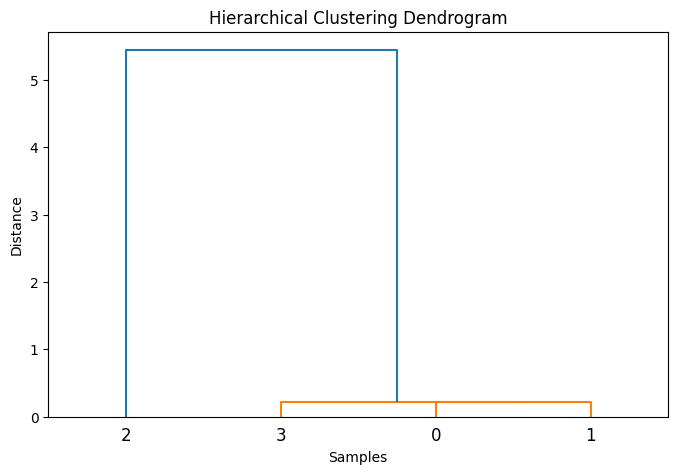

In [13]:
plt.figure(
    figsize=(8,5)
)

dendrogram(
    linkage_matrix
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Distance"
)

plt.show()

### Dendrogram Analysis

The dendrogram visualizes the order and distance of cluster merging in hierarchical clustering.

The first two merges occur at a small distance (0.2236), showing high similarity between points inside each group.

The final merge occurs at a much larger distance (5.4451), indicating that the main groups are significantly separated.

The height of the dendrogram can be used to determine the appropriate number of clusters by selecting a distance threshold.

<h3> Step 3: Hierarchical Clustering on Iris Dataset

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

Scaling:

Hierarchical methods—such as K-Means and DBSCAN—operate based on distance.

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

In [16]:
iris_hc = HierarchicalClustering(
    n_clusters=1
)

iris_hc.fit(
    X_scaled
)

iris_linkage = iris_hc.get_linkage_matrix()

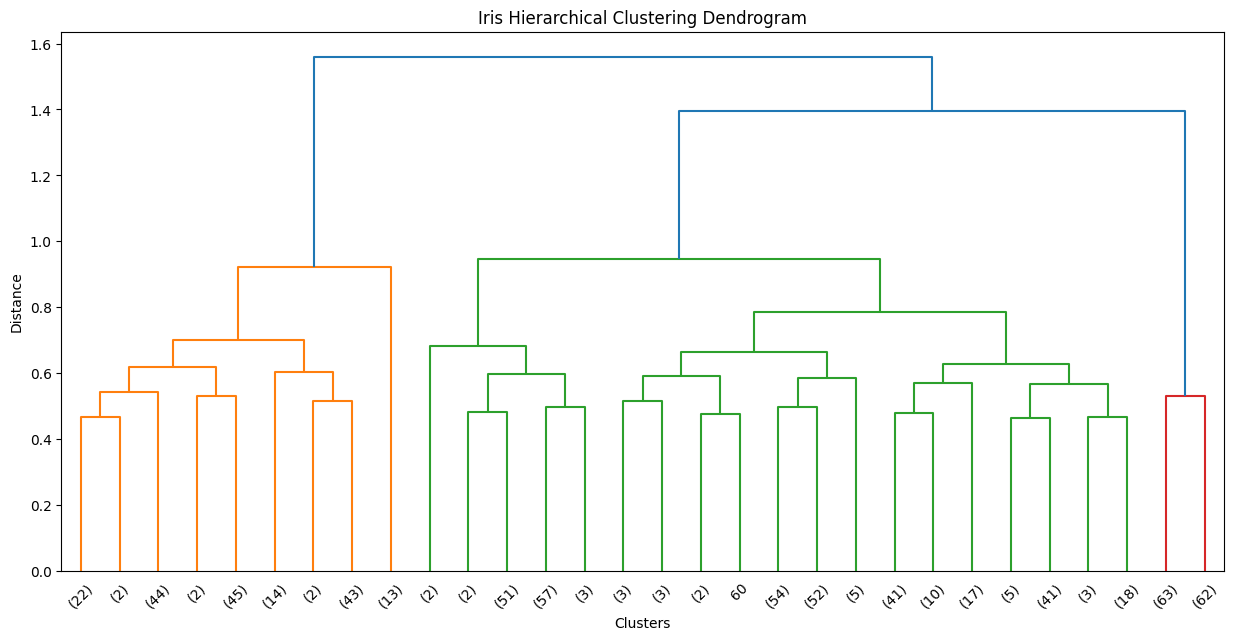

In [17]:
plt.figure(
    figsize=(15,7)
)

dendrogram(
    iris_linkage,
    truncate_mode="lastp",
    p=30
)

plt.title(
    "Iris Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Clusters"
)

plt.ylabel(
    "Distance"
)

plt.show()

This output illustrates an important point regarding hierarchical clustering:
The choice of linkage is crucial.
We are currently using single linkage; if we were to use Ward linkage, the result would likely be closer to a 50/50/50 split,
because Ward linkage aims to minimize the increase in variance resulting from a merge.

In [18]:
iris_hc = HierarchicalClustering(
    n_clusters=3
)

iris_hc.fit(
    X_scaled
)

hc_labels = iris_hc.labels

np.unique(
    hc_labels,
    return_counts=True
)

(array([0, 1, 2]), array([  1,  49, 100], dtype=int64))

<h3> Step 4: Visualization with PCA

In [20]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

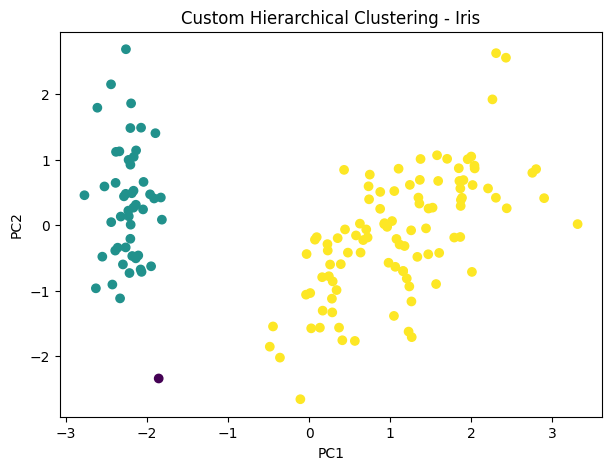

In [21]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels
)

plt.title(
    "Custom Hierarchical Clustering - Iris"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.show()

### Hierarchical Clustering on Iris Dataset

The custom Agglomerative Hierarchical Clustering was applied to the Iris dataset after feature standardization.

The dendrogram shows the hierarchical merging process. Large distance increases indicate natural separation points between clusters.

Using Single Linkage, the algorithm identified three clusters:

| Cluster | Samples |
|---|---:|
|0|1|
|1|49|
|2|100|

The result demonstrates the chaining effect of Single Linkage, where overlapping groups such as Versicolor and Virginica can be merged into a larger cluster.

The choice of linkage method has a significant impact on hierarchical clustering results.

<h3> Step 5: Custom Hierarchical Clustering vs Scikit-Learn AgglomerativeClustering

In [23]:
sklearn_hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="single"
)

sklearn_labels = sklearn_hc.fit_predict(
    X_scaled
)

np.unique(
    sklearn_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([100,   1,  49], dtype=int64))

Comparison with ARI

In [25]:
ari_custom_sklearn = adjusted_rand_score(
    hc_labels,
    sklearn_labels
)

print(
    ari_custom_sklearn
)

1.0


In [26]:
ari_custom_truth = adjusted_rand_score(
    y,
    hc_labels
)

print(
    ari_custom_truth
)

ari_sklearn_truth = adjusted_rand_score(
    y,
    sklearn_labels
)

print(
    ari_sklearn_truth
)

0.5583714437541352
0.5583714437541352


<h3> Step 6: Ward Linkage Test

In [28]:
ward_hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

ward_labels = ward_hc.fit_predict(
    X_scaled
)

np.unique(
    ward_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([71, 49, 30], dtype=int64))

In [29]:
ward_ari = adjusted_rand_score(
    y,
    ward_labels
)

print(
    ward_ari
)

0.6153229932145449


Final Visualization

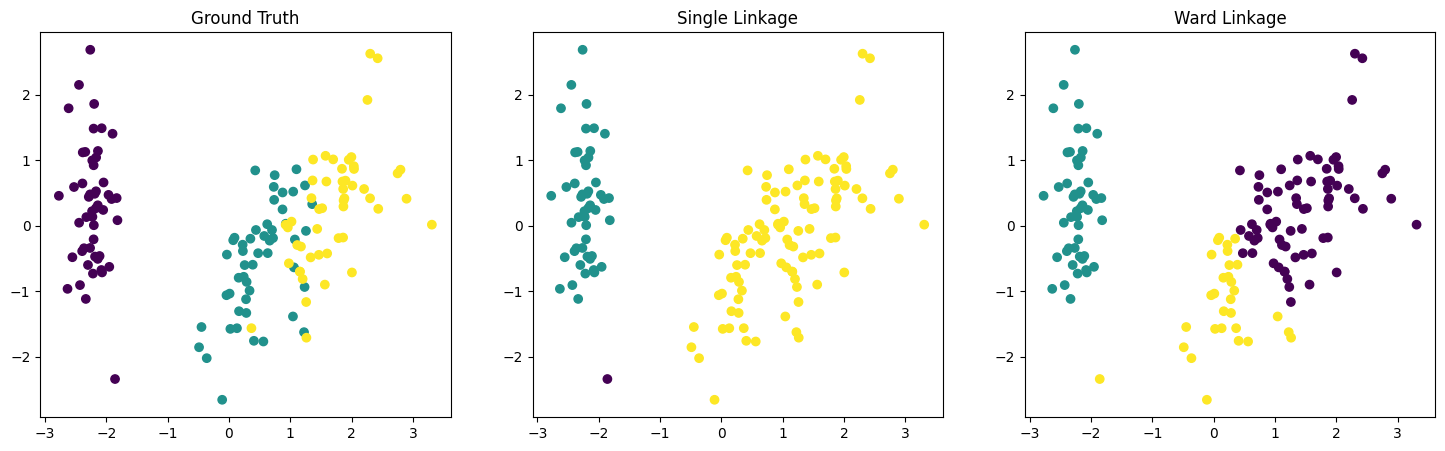

In [30]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

axes[0].set_title(
    "Ground Truth"
)

axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels
)

axes[1].set_title(
    "Single Linkage"
)


axes[2].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=ward_labels
)

axes[2].set_title(
    "Ward Linkage"
)

plt.show()

### Hierarchical Clustering Visualization Analysis

The visualization compares Ground Truth labels with Single Linkage and Ward Linkage clustering results.

Single Linkage successfully separates the Setosa class but merges Versicolor and Virginica due to the chaining effect. This happens because Single Linkage considers only the minimum distance between clusters.

Ward Linkage produces more compact clusters by minimizing the increase in within-cluster variance during merging. As a result, it achieves a higher Adjusted Rand Index compared to Single Linkage.

The experiment demonstrates that the choice of linkage method has a significant impact on hierarchical clustering performance.